# The floruit field
What `Individual.floruit_date` holds: its format, where its values come from, how precise they are, and how the individuals who have one are spread by cross-verified occupation, century and region.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import polars as pl
from style import *

DB_PATH = '../data/cultura/humans_clean_v2.duckdb'
CV_PATH = '../data/similar_databases/cross_verified.duckdb'

FIRST_CENTURY = -1000
LAST_CENTURY = 2000
PRECISION_ORDER = ['day', 'month', 'year', 'decade', 'century', 'millennium']
PRECISION_COLORS = {'day': NAVY, 'month': DARK_BLUE, 'year': BLUE, 'decade': LIGHT_BLUE, 'century': ORANGE, 'millennium': RED}

pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(80)

apply_style()

connection = duckdb.connect(DB_PATH, read_only=True)
connection.execute(f"ATTACH '{CV_PATH}' AS cv (READ_ONLY)")

## Format
`floruit_date` is a list of `Date` structs, one per source. Each `Date` has `iso` (the ISO string, empty for a bare year), `year` (negative before the common era), `precision` (day → millennium) and its own `field_provenance`. The Wikidata value comes from property P1317, *floruit*: a date when the person is known to have been active, usually because nothing better is known.

In [2]:
connection.execute('''
    SELECT count(*) AS individuals,
           count(*) FILTER (WHERE len(floruit_date) > 0) AS with_floruit,
           max(len(floruit_date)) AS most_entries_on_one_individual
    FROM individual
''').pl()

individuals,with_floruit,most_entries_on_one_individual
i64,i64,i64
13002897,70521,1


In [3]:
connection.execute('''
    SELECT individual.entity.label_en AS name, individual.entity.description,
           floruit_date[1].iso AS iso, floruit_date[1].year AS year, floruit_date[1].precision AS precision,
           floruit_date[1].field_provenance['year'].raw AS provenance_raw
    FROM individual
    WHERE len(floruit_date) > 0
    ORDER BY hash(individual.entity.qid)
    LIMIT 8
''').pl()

name,description,iso,year,precision,provenance_raw
str,str,str,i64,str,list[str]
"""Florentius""",null,"""0300-01-01""",300,"""century""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
null,null,"""1177-01-01""",1177,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Ingela M Grumme""",null,"""2014-01-01""",2014,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Rein van Houts""",null,"""1945-01-01""",1945,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Walter G. Joyce""","""American/Swiss paleontologist""","""2015-01-01""",2015,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Hillary Joy Kipnis""",null,"""1987-01-01""",1987,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""T. Chaduk""","""voice actor (fl. in the 1930s)""","""1930-01-01""",1930,"""decade""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Johannes von Magdeburg""",null,"""1250-01-01""",1250,"""century""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"


## Load the floruit individuals
One row per individual: the floruit year, its precision and source, the cross-verified category, and a region.

- **Source**: an entry whose provenance carries the `wikipedia_dates` prompt was read from the Wikipedia article by a language model; every other entry is Wikidata P1317.
- **Category**: `level1_main_occ` from the cross-verified database, `Not in CV` for anyone it does not hold.
- **Region**: the continent of the present-day state of the birthplace's country, else the deathplace's country, else the first country of citizenship. `No location` when none of these is known.

In [4]:
floruit = connection.execute('''
    SELECT individual.entity.qid AS qid,
           floruit_date[1].year AS year,
           coalesce(floruit_date[1].precision, 'unknown') AS precision,
           CASE WHEN floruit_date[1].field_provenance['year'].ai_answer.prompt_id = 'wikipedia_dates'
                THEN 'Wikipedia article' ELSE 'Wikidata P1317' END AS source,
           len(birth_date) > 0 AS has_birth,
           len(death_date) > 0 AS has_death,
           coalesce(cv.level1_main_occ, 'Not in CV') AS category,
           coalesce(birth_country.present_day_state.continent,
                    death_country.present_day_state.continent,
                    citizenship.present_day_state.continent,
                    'No location') AS region
    FROM individual
    LEFT JOIN cv.individuals AS cv ON cv.wikidata_code = individual.entity.qid
    LEFT JOIN place AS birthplace ON birthplace.entity.qid = individual.place_of_birth.entity.qid
    LEFT JOIN place AS birth_country ON birth_country.entity.qid = birthplace.country.qid
    LEFT JOIN place AS deathplace ON deathplace.entity.qid = individual.place_of_death.entity.qid
    LEFT JOIN place AS death_country ON death_country.entity.qid = deathplace.country.qid
    LEFT JOIN place AS citizenship ON citizenship.entity.qid = individual.country_of_citizenship[1].entity.qid
    WHERE len(floruit_date) > 0
''').pl().with_columns((pl.col('year') // 100 * 100).alias('century_start'))

print(f'{len(floruit):,} individuals with a floruit')

70,521 individuals with a floruit


## Source and precision

In [5]:
floruit.group_by('source', 'precision').len().sort('source', 'len', descending=[False, True])

source,precision,len
str,str,u32
"""Wikidata P1317""","""year""",52006
"""Wikidata P1317""","""century""",12637
"""Wikidata P1317""","""decade""",2429
"""Wikidata P1317""","""day""",1051
"""Wikidata P1317""","""month""",349
"""Wikidata P1317""","""millennium""",166
"""Wikidata P1317""","""unknown""",3
"""Wikipedia article""","""year""",1880


## Other dates beside the floruit
For most of these individuals the floruit is the only date there is.

In [6]:
floruit.group_by('has_birth', 'has_death').len().sort('len', descending=True).with_columns(
    (pl.col('len') / pl.col('len').sum() * 100).round(1).alias('percent')
)

has_birth,has_death,len,percent
bool,bool,u32,f64
false,false,46375,65.8
true,true,12100,17.2
true,false,10568,15.0
false,true,1478,2.1


## By century
The century is the floruit year floored to the hundred, so `1400` covers 1400–1499. A century-precision value is placed by the year Wikidata stores for it, which can fall at the start or the end of that century. Bars are split by precision.

179 individuals before -1000 left out of the chart
57 individuals with a floruit after 2099 — data errors — left out of the chart


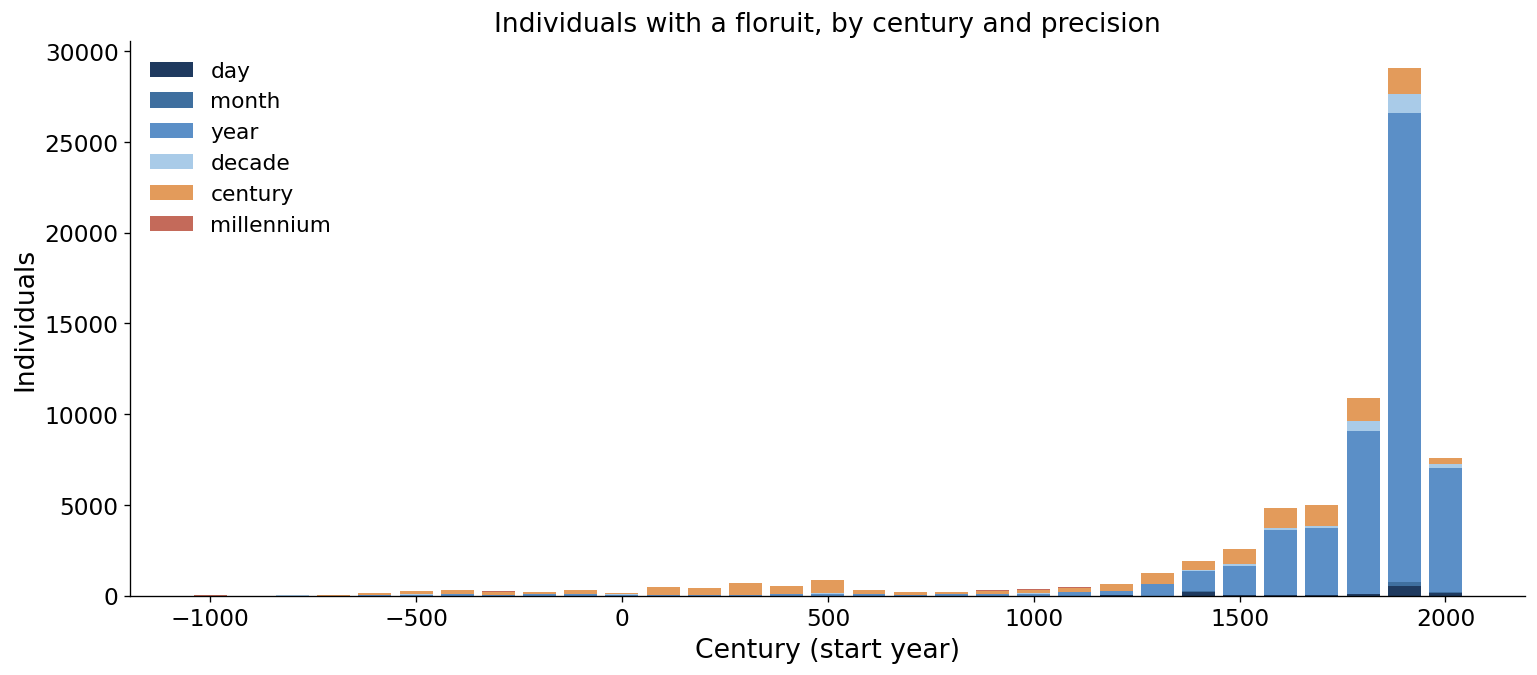

In [7]:
by_century = (
    floruit.filter(pl.col('century_start').is_between(FIRST_CENTURY, LAST_CENTURY))
    .group_by('century_start', 'precision').len()
    .pivot(on='precision', index='century_start', values='len')
    .fill_null(0)
    .sort('century_start')
)
print(f"{floruit.filter(pl.col('century_start') < FIRST_CENTURY).height:,} individuals before {FIRST_CENTURY} left out of the chart")
print(f"{floruit.filter(pl.col('century_start') > LAST_CENTURY).height:,} individuals with a floruit after {LAST_CENTURY + 99} — data errors — left out of the chart")

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
bottom = [0] * by_century.height
for precision in PRECISION_ORDER:
    if precision not in by_century.columns:
        continue
    values = by_century[precision].to_list()
    ax.bar(by_century['century_start'], values, width=80, bottom=bottom, color=PRECISION_COLORS[precision], label=precision)
    bottom = [b + v for b, v in zip(bottom, values)]
ax.set_xlabel('Century (start year)')
ax.set_ylabel('Individuals')
ax.set_title('Individuals with a floruit, by century and precision')
ax.legend()
plt.show()

In [8]:
floruit.group_by('century_start').len().sort('century_start').filter(pl.col('century_start').is_between(FIRST_CENTURY, LAST_CENTURY)).with_columns(
    (pl.col('len') / pl.col('len').sum() * 100).round(1).alias('percent')
)

century_start,len,percent
i64,u32,f64
-1000,16,0.0
-900,5,0.0
-800,23,0.0
-700,32,0.0
-600,129,0.2
-500,261,0.4
-400,302,0.4
-300,231,0.3
-200,213,0.3


## By cross-verified occupation category

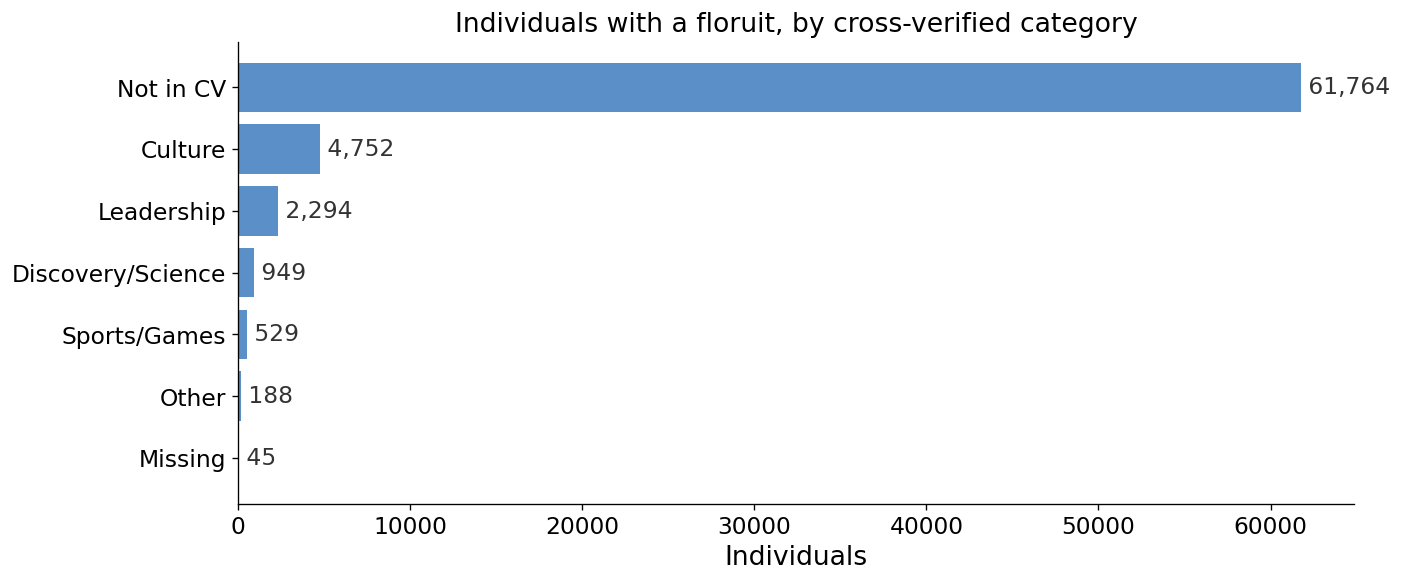

In [9]:
by_category = floruit.group_by('category').len().sort('len')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.barh(by_category['category'], by_category['len'], color=MAIN_COLOR)
for y, value in enumerate(by_category['len']):
    ax.text(value, y, f' {value:,}', va='center', color=TEXT)
ax.set_xlabel('Individuals')
ax.set_title('Individuals with a floruit, by cross-verified category')
plt.show()

## By region

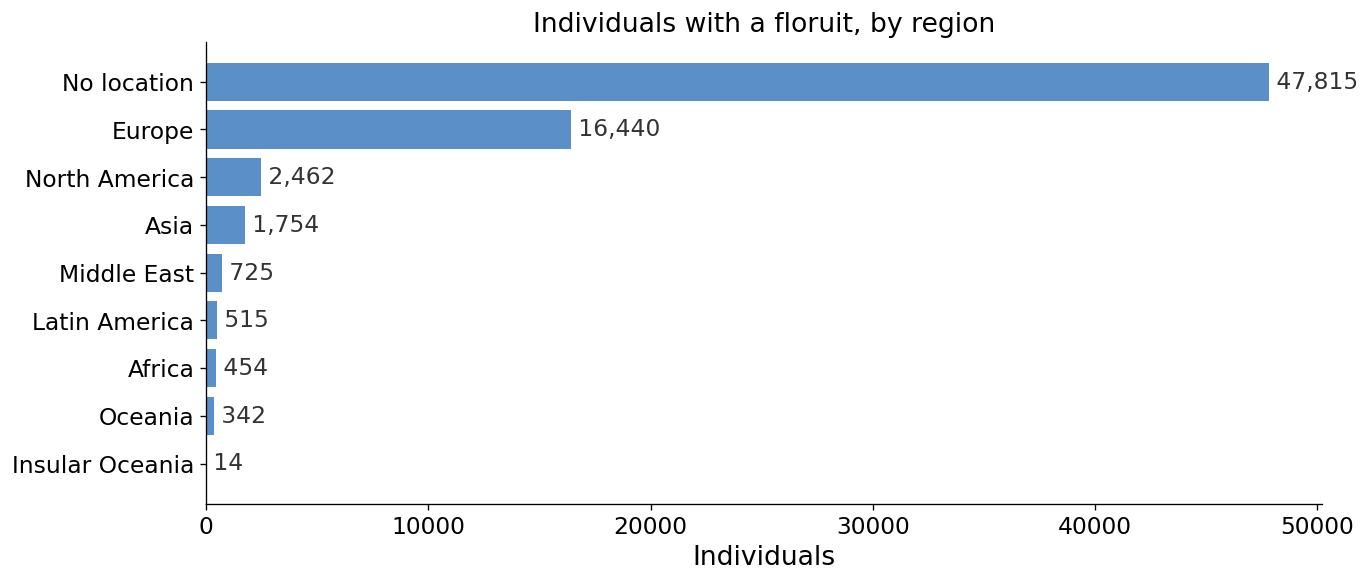

In [10]:
by_region = floruit.group_by('region').len().sort('len')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.barh(by_region['region'], by_region['len'], color=MAIN_COLOR)
for y, value in enumerate(by_region['len']):
    ax.text(value, y, f' {value:,}', va='center', color=TEXT)
ax.set_xlabel('Individuals')
ax.set_title('Individuals with a floruit, by region')
plt.show()

## Category and region by century
Counts per century for the main breakdowns, from the year 1000.

In [11]:
(
    floruit.filter(pl.col('century_start').is_between(1000, LAST_CENTURY))
    .group_by('century_start', 'category').len()
    .pivot(on='category', index='century_start', values='len')
    .fill_null(0)
    .sort('century_start')
    .select('century_start', *floruit.group_by('category').len().sort('len', descending=True)['category'])
)

century_start,Not in CV,Culture,Leadership,Discovery/Science,Sports/Games,Other,Missing
i64,u32,u32,u32,u32,u32,u32,u32
1000,250,43,65,15,0,2,0
1100,320,36,71,19,0,2,3
1200,457,104,74,16,0,4,5
1300,981,142,108,23,0,3,1
1400,1641,149,90,16,1,13,1
1500,2221,196,67,47,1,16,2
1600,4387,234,74,77,2,28,3
1700,4626,208,75,44,7,32,1
1800,10302,367,91,101,35,14,3


In [12]:
(
    floruit.filter(pl.col('century_start').is_between(1000, LAST_CENTURY))
    .group_by('century_start', 'region').len()
    .pivot(on='region', index='century_start', values='len')
    .fill_null(0)
    .sort('century_start')
    .select('century_start', *floruit.group_by('region').len().sort('len', descending=True)['region'])
)

century_start,No location,Europe,North America,Asia,Middle East,Latin America,Africa,Oceania,Insular Oceania
i64,u32,u32,u32,u32,u32,u32,u32,u32,u32
1000,269,83,0,9,14,0,0,0,0
1100,355,76,0,9,10,0,1,0,0
1200,463,183,1,6,6,0,0,1,0
1300,1000,236,0,7,14,0,1,0,0
1400,1538,340,1,12,15,0,5,0,0
1500,1919,594,1,17,10,6,3,0,0
1600,3908,838,3,23,9,21,3,0,0
1700,4008,889,25,32,14,19,6,0,0
1800,7640,2648,324,176,18,45,11,51,0
